### Preprocessing (with interpolation)

In [ ]:
import pandas as pd
import numpy as np 

df_california = pd.read_csv('california_full_unique.csv')
df_arkansas = pd.read_csv('arkansas_full_unique.csv')

band_cols = [col for col in df_california.columns if col != 'cropland']

df_california[band_cols] = df_california[band_cols].replace(0, np.nan)
df_arkansas[band_cols] = df_arkansas[band_cols].replace(0, np.nan)

num_cal=(df_california.isnull().sum(axis=1) > 0).sum()
num_ark=(df_arkansas.isnull().sum(axis=1) > 0).sum()

num_cal_zero=(df_california.isin([0]).sum(axis=1) > 0).sum()
num_ark_zero=(df_arkansas.isin([0]).sum(axis=1) > 0).sum()

print(num_cal_zero)
print(num_ark_zero)
print(num_cal)
print(num_ark)
print(len(df_california))
print(len(df_arkansas))

BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

for band in BANDS:
    cols = [f'd{i}_{band}' for i in range(36)]
    df_arkansas[cols]= df_arkansas[cols].interpolate(axis=1, limit_direction='both')
    df_california[cols] = df_california[cols].interpolate(axis=1, limit_direction='both')


num_cal_after = (df_california.isnull().sum(axis=1) > 0).sum()
num_ark_after = (df_arkansas.isnull().sum(axis=1) > 0).sum()

print(num_cal_after)
print(num_ark_after)


band_cols = [col for col in df_california.columns if col not in ['cropland', '.geo']]

df_california[band_cols] = df_california[band_cols] / 10000
df_arkansas[band_cols] = df_arkansas[band_cols] / 10000

print(df_california[band_cols].max().max())
print(df_california[band_cols].min().min())

for i in range(36):
    nir = df_california[f'd{i}_B8']
    red = df_california[f'd{i}_B4']
    df_california[f'ndvi_{i}'] = (nir - red) / (nir + red)

for i in range(36):
    nir = df_arkansas[f'd{i}_B8']
    red = df_arkansas[f'd{i}_B4']
    df_arkansas[f'ndvi_{i}'] = (nir - red) / (nir + red)
    
print(df_california[[f'ndvi_{i}' for i in range(36)]].max().max())
print(df_california[[f'ndvi_{i}' for i in range(36)]].min().min())

df_california.to_csv('california_preprocessed.csv', index=False)
df_arkansas.to_csv('arkansas_preprocessed.csv', index=False)
    


0
0
23744
36519
30412
36625
0
0
1.569
5e-05
0.9997943233237351
-0.9652173913043477


C:\Users\lhadi\AppData\Local\Temp\ipykernel_22988\207093919.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_california[f'ndvi_{i}'] = (nir - red) / (nir + red)
C:\Users\lhadi\AppData\Local\Temp\ipykernel_22988\207093919.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_arkansas[f'ndvi_{i}'] = (nir - red) / (nir + red)


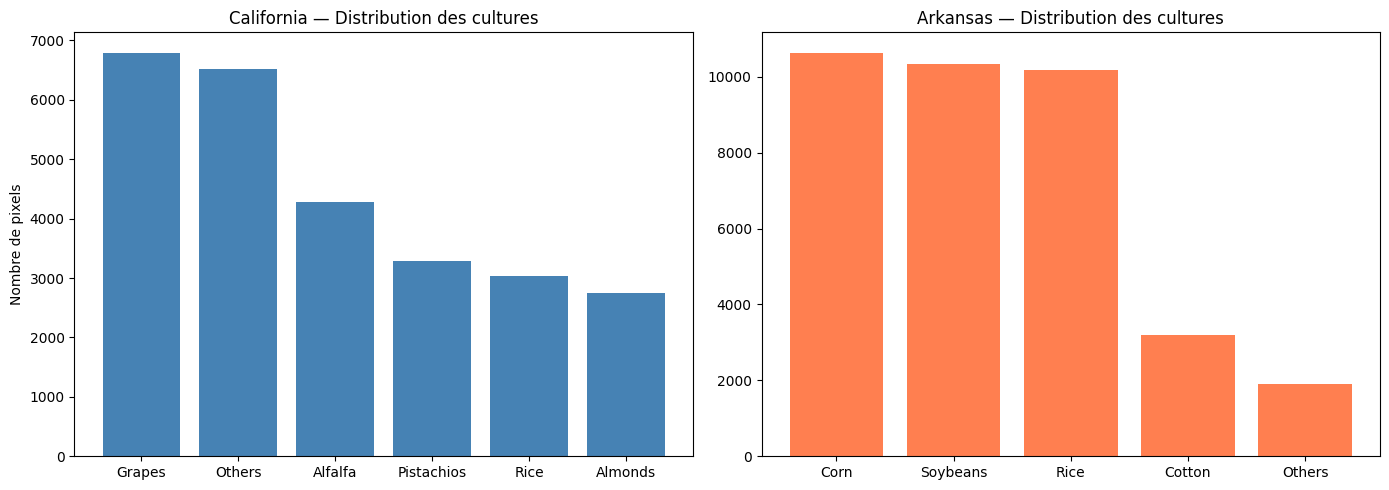

In [32]:
import matplotlib.pyplot as plt

# Mapping des classes
mapping_ca = {3: 'Rice', 36: 'Alfalfa', 69: 'Grapes', 75: 'Almonds', 76: 'Pistachios', 176: 'Others'}
mapping_ar = {1: 'Soybeans', 2: 'Cotton', 3: 'Rice', 5: 'Corn', 176: 'Others'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# California
counts_ca = df_california['cropland'].map(mapping_ca).value_counts()
axes[0].bar(counts_ca.index, counts_ca.values, color='steelblue')
axes[0].set_title('California — Distribution des cultures')
axes[0].set_ylabel('Nombre de pixels')

# Arkansas
counts_ar = df_arkansas['cropland'].map(mapping_ar).value_counts()
axes[1].bar(counts_ar.index, counts_ar.values, color='coral')
axes[1].set_title('Arkansas — Distribution des cultures')

plt.tight_layout()
plt.savefig('distribution_classes.png', dpi=150)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ndvi_cols = [f'ndvi_{i}' for i in range(36)]
x = range(36)

# California
for code, name in mapping_ca.items():
    subset = df_california[df_california['cropland'] == code]
    mean_ndvi = subset[ndvi_cols].mean()
    axes[0].plot(x, mean_ndvi, label=name, linewidth=2)

axes[0].set_title('California — NDVI par culture')
axes[0].set_xlabel('Date (0=jan, 35=dec)')
axes[0].set_ylabel('NDVI moyen')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Arkansas
for code, name in mapping_ar.items():
    subset = df_arkansas[df_arkansas['cropland'] == code]
    mean_ndvi = subset[ndvi_cols].mean()
    axes[1].plot(x, mean_ndvi, label=name, linewidth=2)

axes[1].set_title('Arkansas — NDVI par culture')
axes[1].set_xlabel('Date (0=jan, 35=dec)')
axes[1].set_ylabel('NDVI moyen')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ndvi_timeseries.png', dpi=150)
plt.show()

---

### Preprocessing (without interpolation)

In [1]:
import pandas as pd
import numpy as np


df_california = pd.read_csv('california_full_unique.csv')
df_arkansas = pd.read_csv('arkansas_full_unique.csv')

band_cols = [col for col in df_california.columns if col not in ['cropland', '.geo']]

# we replace 0 temporarily with NaN to avoid issues in NDVI calculation (division by zero or invalid NDVI values)
df_california[band_cols] = df_california[band_cols].replace(0, np.nan)
df_arkansas[band_cols] = df_arkansas[band_cols].replace(0, np.nan)


df_california[band_cols] = df_california[band_cols] / 10000
df_arkansas[band_cols] = df_arkansas[band_cols] / 10000

# nvdi
for i in range(36):
    
    nir_cal = df_california[f'd{i}_B8']
    red_cal = df_california[f'd{i}_B4']
    df_california[f'ndvi_{i}'] = (nir_cal - red_cal) / (nir_cal + red_cal)
    
    
    nir_ark = df_arkansas[f'd{i}_B8']
    red_ark = df_arkansas[f'd{i}_B4']
    df_arkansas[f'ndvi_{i}'] = (nir_ark - red_ark) / (nir_ark + red_ark)

#Replace all nan with 0

df_california = df_california.fillna(0)
df_arkansas = df_arkansas.fillna(0)


df_california.to_csv('california_preprocessed_v2.csv', index=False)
df_arkansas.to_csv('arkansas_preprocessed_v2.csv', index=False)

print("Prétraitement terminé : Normalisation effectuée et valeurs manquantes marquées par 0.")

/tmp/ipykernel_8746/226515520.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_california[f'ndvi_{i}'] = (nir_cal - red_cal) / (nir_cal + red_cal)
/tmp/ipykernel_8746/226515520.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_arkansas[f'ndvi_{i}'] = (nir_ark - red_ark) / (nir_ark + red_ark)


Prétraitement terminé : Normalisation effectuée et valeurs manquantes marquées par 0.
